In [22]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
import matplotlib.pyplot as plt
import numpy as np
import mlflow
import os

In [5]:
diabetes_df = pd.read_csv("./data/diabetes_clean.csv")
diabetes_df.head()

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Linear Regression with SKLearn

In [ ]:
# single

In [10]:
X = diabetes_df.drop(columns=["diabetes"])
y = diabetes_df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
reg_all = LinearRegression()
reg_all.fit(X_train, y_train)
y_pred = reg_all.predict(X_test)

## Accuracy Metrics

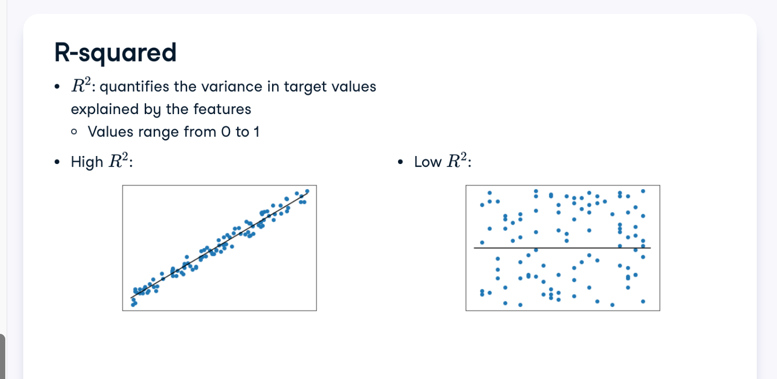

* $r^2$ can be directly recieved with .score()
* adjusted $r^2$ isnt implemented

In [15]:
r2_score = reg_all.score(X_test, y_test)
r2_score

0.25500281176741746

In [20]:
# adjusted r2
p = X.shape[1]
n = X.shape[0]

adjusted_r2 = 1 - (1 - r2_score) * (n - 1) / (n - p - 1)
adjusted_r2

0.24715040398630983

# K-fold Cross Validation (with different groupings)
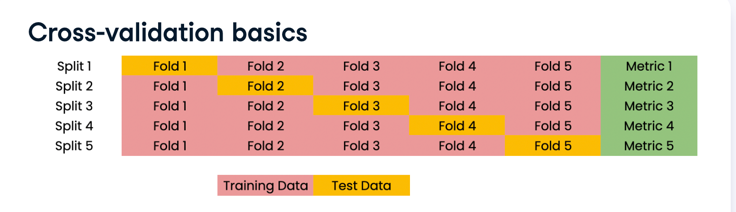



In [23]:
kf = KFold(n_splits=6, shuffle=True, random_state=42)
cv_results = cross_val_score(reg_all, X_train, y_train, cv=kf)
cv_results #score = r squared

array([0.29108085, 0.31176698, 0.22845595, 0.25861182, 0.21914363,
       0.2882459 ])

In [24]:
np.mean(cv_results)

np.float64(0.2662175214959535)

In [25]:
np.std(cv_results)

np.float64(0.03385735333812089)

In [26]:
np.quantile(cv_results, [0.25, 0.975])

array([0.23599492, 0.30918122])

# Regularization/ Regularized Regression

### Ridge Regression

w# Logistic Regresion
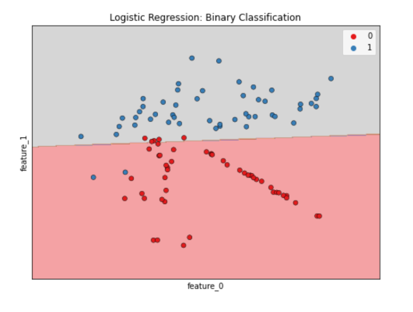
### predicting probabilities
